# Notebook 2 — Basic GANs

**Phase 2** deliverable. Learning objectives:
- Vanilla GAN architecture
- DCGAN with best practices
- Conditional GAN for controlled generation
- Detecting & addressing mode collapse
- Wasserstein GAN for training stability

Complete the TODOs in `models/gans/` and `training/losses.py` (adversarial,
WGAN, and gradient-penalty losses) before running the training cells. Run
`pytest -m gan -v` to check your progress.


In [1]:
import sys
from pathlib import Path

# Make `generative_art_studio` importable without `pip install -e .`
REPO_ROOT = Path.cwd().parent if (Path.cwd() / "notebooks").exists() else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

import torch
# Ensure the project root is used when the notebook is launched from the notebooks folder.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_PATH = REPO_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from generative_art_studio.utils import set_seed, plot_image_grid
from generative_art_studio.config import DEVICE

set_seed(42)
print(f"Using device: {DEVICE}")


Using device: cpu


In [2]:
from generative_art_studio.data import SyntheticImageDataset, get_dataloader

dataset = SyntheticImageDataset(num_samples=256, image_size=64, num_classes=2)
dataloader = get_dataloader(dataset, batch_size=32)


## 1. Vanilla GAN (fully-connected) — reference architecture

In [3]:
from generative_art_studio.models.gans import VanillaGenerator, VanillaDiscriminator
from generative_art_studio.training.train_gan import train_gan
from torch.optim import Adam

latent_dim = 64
generator = VanillaGenerator(latent_dim=latent_dim).to(DEVICE)
discriminator = VanillaDiscriminator().to(DEVICE)

g_opt = Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
d_opt = Adam(discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))

history = train_gan(generator, discriminator, dataloader, g_opt, d_opt, latent_dim, device=DEVICE, epochs=3)


GAN epoch 1/3:   0%|          | 0/8 [00:00<?, ?it/s]

GAN epoch 2/3:   0%|          | 0/8 [00:00<?, ?it/s]

GAN epoch 3/3:   0%|          | 0/8 [00:00<?, ?it/s]

In [4]:
import matplotlib.pyplot as plt
plt.plot(history.g_loss, label="G loss")
plt.plot(history.d_loss, label="D loss")
plt.legend(); plt.title("Vanilla GAN training — watch for D loss collapsing near 0 (mode collapse warning sign)")
plt.show()

from generative_art_studio.utils.latent_space import sample_latent
z = sample_latent(16, latent_dim, DEVICE)
samples = generator(z)
plot_image_grid(samples.detach().cpu(), nrow=4, title="Vanilla GAN samples")


C:\Users\jbisw\AppData\Local\Temp\ipykernel_32528\1744527637.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


<Figure size 400x400 with 1 Axes>

## 2. DCGAN

Implement `DCGANGenerator`/`DCGANDiscriminator` in `models/gans/dcgan.py`,
then repeat the training loop above with these models (remember to call
`.apply(weights_init_dcgan)` right after construction) and `latent_dim=100`.


Epoch [1/25]  Loss_D: 0.3002  Loss_G: 3.9663
Epoch [2/25]  Loss_D: 0.1754  Loss_G: 5.9148
Epoch [3/25]  Loss_D: 0.0861  Loss_G: 6.5677
Epoch [4/25]  Loss_D: 0.0565  Loss_G: 6.5026
Epoch [5/25]  Loss_D: 0.0541  Loss_G: 7.0360
Epoch [6/25]  Loss_D: 0.0440  Loss_G: 7.2858
Epoch [7/25]  Loss_D: 0.0347  Loss_G: 7.8554
Epoch [8/25]  Loss_D: 0.0283  Loss_G: 7.1946
Epoch [9/25]  Loss_D: 0.0251  Loss_G: 7.4939
Epoch [10/25]  Loss_D: 0.0374  Loss_G: 8.6451
Epoch [11/25]  Loss_D: 0.0356  Loss_G: 9.9295
Epoch [12/25]  Loss_D: 0.0178  Loss_G: 7.2783
Epoch [13/25]  Loss_D: 0.0210  Loss_G: 13.0463
Epoch [14/25]  Loss_D: 0.0029  Loss_G: 13.4124
Epoch [15/25]  Loss_D: 0.0078  Loss_G: 7.3356
Epoch [16/25]  Loss_D: 0.0382  Loss_G: 12.5642
Epoch [17/25]  Loss_D: 0.0000  Loss_G: 13.3362
Epoch [18/25]  Loss_D: 0.0025  Loss_G: 20.7051
Epoch [19/25]  Loss_D: 0.0026  Loss_G: 14.8492
Epoch [20/25]  Loss_D: 0.0228  Loss_G: 17.8233
Epoch [21/25]  Loss_D: 0.0101  Loss_G: 9.1605
Epoch [22/25]  Loss_D: 1.5777  Loss_

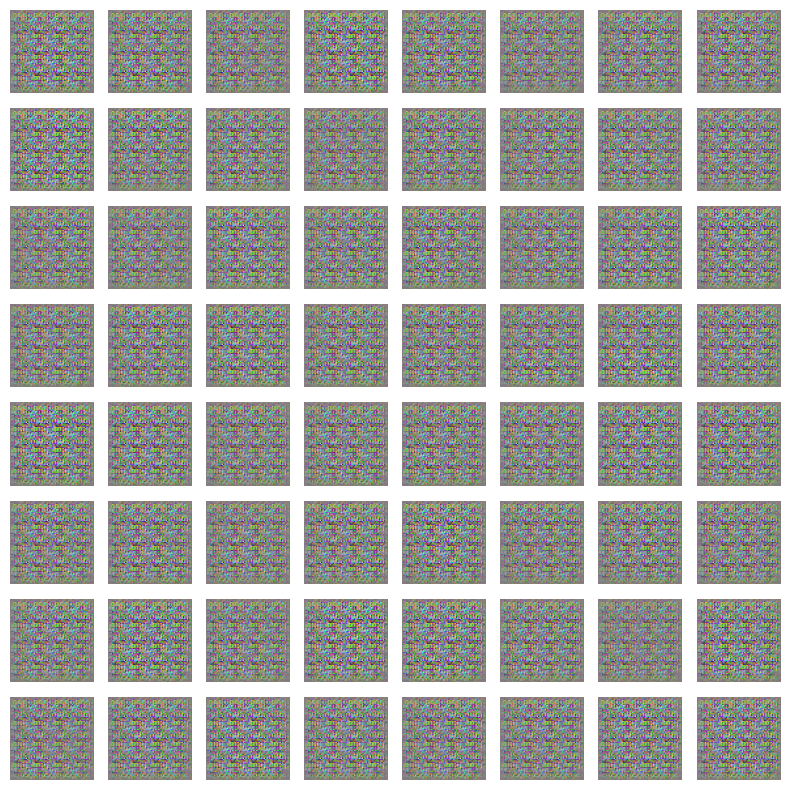

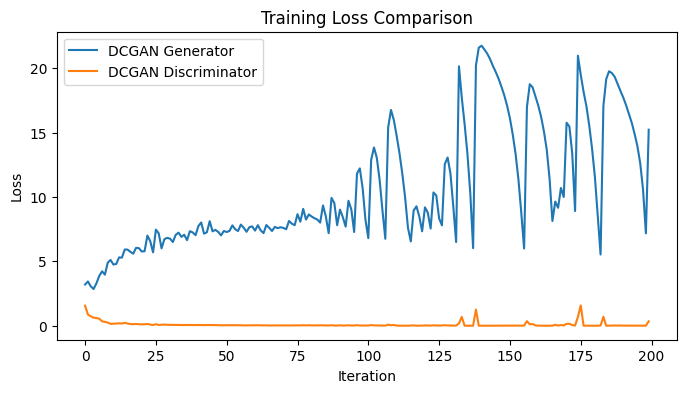

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from generative_art_studio.models.gans import DCGANGenerator, DCGANDiscriminator, weights_init_dcgan

dc_latent_dim = 100
dc_generator = DCGANGenerator(latent_dim=dc_latent_dim, feature_maps=32).to(DEVICE)
dc_discriminator = DCGANDiscriminator(feature_maps=32).to(DEVICE)
dc_generator.apply(weights_init_dcgan)
dc_discriminator.apply(weights_init_dcgan)

# TODO: train dc_generator/dc_discriminator the same way as the vanilla GAN above,
# then visualize samples and compare training-curve stability.

import torch.optim as optim
import matplotlib.pyplot as plt

criterion = nn.BCELoss()
lr = 2e-4
beta1 = 0.5

optimizerD = optim.Adam(dc_discriminator.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(dc_generator.parameters(), lr=lr, betas=(beta1, 0.999))

fixed_noise = torch.randn(64, dc_latent_dim, device=DEVICE)
real_label, fake_label = 1.0, 0.0

num_epochs = 25
dc_G_losses, dc_D_losses = [], []

for epoch in range(num_epochs):
    for i, (real_imgs, _) in enumerate(dataloader):
        real_imgs = real_imgs.to(DEVICE)
        b_size = real_imgs.size(0)

        # ---- Train Discriminator: maximize log(D(x)) + log(1 - D(G(z))) ----
        dc_discriminator.zero_grad()
        label = torch.full((b_size, 1), real_label, device=DEVICE)
        output = dc_discriminator(real_imgs)
        lossD_real = criterion(output, label)
        lossD_real.backward()

        noise = torch.randn(b_size, dc_latent_dim, device=DEVICE)
        fake = dc_generator(noise)
        label.fill_(fake_label)
        output = dc_discriminator(fake.detach())
        lossD_fake = criterion(output, label)
        lossD_fake.backward()

        lossD = lossD_real + lossD_fake
        optimizerD.step()

        # ---- Train Generator: maximize log(D(G(z))) ----
        dc_generator.zero_grad()
        label.fill_(real_label)  # generator wants D to think these are real
        output = dc_discriminator(fake)
        lossG = criterion(output, label)
        lossG.backward()
        optimizerG.step()

        dc_G_losses.append(lossG.item())
        dc_D_losses.append(lossD.item())

    print(f"Epoch [{epoch+1}/{num_epochs}]  Loss_D: {lossD.item():.4f}  Loss_G: {lossG.item():.4f}")
%matplotlib inline
# ---- Visualize samples ----
dc_generator.eval()
with torch.no_grad():
    samples = dc_generator(fixed_noise).cpu()
dc_generator.train()

fig, axes = plt.subplots(8, 8, figsize=(8, 8))
for ax, img in zip(axes.flatten(), samples):
    img = (img * 0.5 + 0.5).permute(1, 2, 0).numpy()  # unnormalize from [-1,1]
    ax.imshow(img.squeeze(), cmap="gray" if img.shape[-1] == 1 else None)
    ax.axis("off")
plt.tight_layout()
plt.show()

# ---- Compare training-curve stability ----
plt.figure(figsize=(8, 4))
plt.plot(dc_G_losses, label="DCGAN Generator")
plt.plot(dc_D_losses, label="DCGAN Discriminator")
# if you saved vanilla-GAN losses earlier as G_losses/D_losses, overlay them:
# plt.plot(G_losses, label="Vanilla GAN Generator", linestyle="--")
# plt.plot(D_losses, label="Vanilla GAN Discriminator", linestyle="--")
plt.title("Training Loss Comparison")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.show()



## 3. Conditional GAN

Implement `ConditionalGenerator`/`ConditionalDiscriminator` in
`models/gans/conditional_gan.py`, then generate samples per class label to
demonstrate controlled generation.


Epoch [1/25]  Loss_D: 1.3304  Loss_G: 0.7737
Epoch [2/25]  Loss_D: 1.4209  Loss_G: 1.2126
Epoch [3/25]  Loss_D: 1.3732  Loss_G: 1.1010
Epoch [4/25]  Loss_D: 2.5114  Loss_G: 1.0192
Epoch [5/25]  Loss_D: 1.7450  Loss_G: 0.8549
Epoch [6/25]  Loss_D: 1.4195  Loss_G: 1.1161
Epoch [7/25]  Loss_D: 1.1987  Loss_G: 1.4651
Epoch [8/25]  Loss_D: 1.4088  Loss_G: 0.9062
Epoch [9/25]  Loss_D: 1.0295  Loss_G: 2.3323
Epoch [10/25]  Loss_D: 1.1147  Loss_G: 2.6623
Epoch [11/25]  Loss_D: 0.9434  Loss_G: 3.2270
Epoch [12/25]  Loss_D: 1.1404  Loss_G: 4.0034
Epoch [13/25]  Loss_D: 1.1693  Loss_G: 3.1320
Epoch [14/25]  Loss_D: 0.9154  Loss_G: 3.3119
Epoch [15/25]  Loss_D: 0.6696  Loss_G: 3.4900
Epoch [16/25]  Loss_D: 0.4903  Loss_G: 4.3759
Epoch [17/25]  Loss_D: 0.3196  Loss_G: 6.0515
Epoch [18/25]  Loss_D: 7.6438  Loss_G: 8.0086
Epoch [19/25]  Loss_D: 0.6182  Loss_G: 4.5979
Epoch [20/25]  Loss_D: 0.5054  Loss_G: 3.7864
Epoch [21/25]  Loss_D: 0.3502  Loss_G: 6.6881
Epoch [22/25]  Loss_D: 1.4717  Loss_G: 4.78

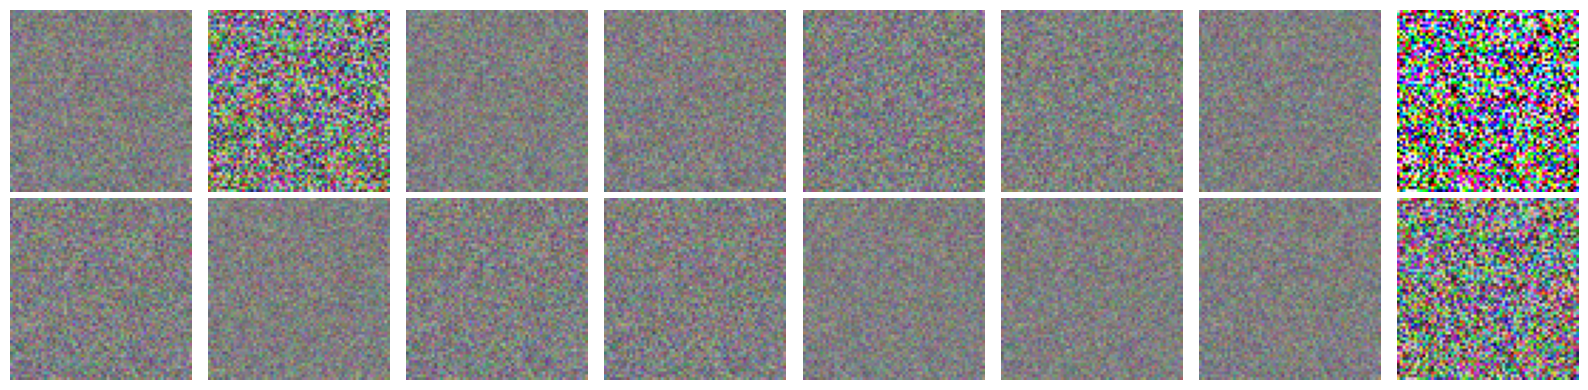

In [11]:
from generative_art_studio.models.gans import ConditionalGenerator, ConditionalDiscriminator

cgan_gen = ConditionalGenerator(latent_dim=64, num_classes=2).to(DEVICE)

# TODO: train, then compare generator output for label=0 vs label=1 with the same z
# z = sample_latent(8, 64, DEVICE)
# samples_label0 = cgan_gen(z, torch.zeros(8, dtype=torch.long, device=DEVICE))
# samples_label1 = cgan_gen(z, torch.ones(8, dtype=torch.long, device=DEVICE))

cgan_disc = ConditionalDiscriminator(num_classes=2).to(DEVICE)

training_cgan = True  # Set to False if you want to skip training and just visualize samples

if training_cgan:
    criterion = nn.BCELoss()
    optimizerD = optim.Adam(cgan_disc.parameters(), lr=2e-4, betas=(0.5, 0.999))
    optimizerG = optim.Adam(cgan_gen.parameters(), lr=2e-4, betas=(0.5, 0.999))

    num_epochs = 25
    for epoch in range(num_epochs):
        for real_imgs, labels in dataloader:  # dataloader must yield (image, class_label)
            real_imgs, labels = real_imgs.to(DEVICE), labels.to(DEVICE)
            b_size = real_imgs.size(0)

            # ---- Train Discriminator ----
            cgan_disc.zero_grad()
            real_target = torch.full((b_size, 1), 1.0, device=DEVICE)
            output_real = cgan_disc(real_imgs, labels)
            lossD_real = criterion(output_real, real_target)

            z = sample_latent(b_size, 64, DEVICE)
            fake_labels = torch.randint(0, 2, (b_size,), device=DEVICE)
            fake_imgs = cgan_gen(z, fake_labels)
            fake_target = torch.full((b_size, 1), 0.0, device=DEVICE)
            output_fake = cgan_disc(fake_imgs.detach(), fake_labels)
            lossD_fake = criterion(output_fake, fake_target)

            lossD = lossD_real + lossD_fake
            lossD.backward()
            optimizerD.step()

            # ---- Train Generator ----
            cgan_gen.zero_grad()
            output = cgan_disc(fake_imgs, fake_labels)
            lossG = criterion(output, real_target)  # wants discriminator to say "real"
            lossG.backward()
            optimizerG.step()

        print(f"Epoch [{epoch+1}/{num_epochs}]  Loss_D: {lossD.item():.4f}  Loss_G: {lossG.item():.4f}")
%matplotlib inline
# ---- Compare label=0 vs label=1 output for the same z ----
cgan_gen.eval()
with torch.no_grad():
    z = sample_latent(8, 64, DEVICE)
    samples_label0 = cgan_gen(z, torch.zeros(8, dtype=torch.long, device=DEVICE))
    samples_label1 = cgan_gen(z, torch.ones(8, dtype=torch.long, device=DEVICE))
cgan_gen.train()

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    img0 = (samples_label0[i] * 0.5 + 0.5).cpu().permute(1, 2, 0).numpy()
    img1 = (samples_label1[i] * 0.5 + 0.5).cpu().permute(1, 2, 0).numpy()
    axes[0, i].imshow(img0.squeeze(), cmap="gray" if img0.shape[-1] == 1 else None)
    axes[0, i].axis("off")
    axes[1, i].imshow(img1.squeeze(), cmap="gray" if img1.shape[-1] == 1 else None)
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("label=0")
axes[1, 0].set_ylabel("label=1")
plt.tight_layout()
plt.show()




## 4. Wasserstein GAN (WGAN-GP)

Implement `WGANCritic` (`models/gans/wgan.py`) and `wgan_critic_loss` /
`wgan_generator_loss` / `gradient_penalty` (`training/losses.py`), then
write your own critic/generator training loop below — unlike the BCE GAN,
WGAN trains the critic `N_CRITIC` steps per generator step (see
`config.N_CRITIC`).


Epoch [1/25]  Loss_C: -0.6056  Loss_G: 2.8318
Epoch [1/25]  Loss_C: -1.9521  Loss_G: 3.5075
Epoch [2/25]  Loss_C: -3.5411  Loss_G: 5.1893
Epoch [2/25]  Loss_C: -3.3516  Loss_G: 5.0361
Epoch [3/25]  Loss_C: -4.3833  Loss_G: 5.9292
Epoch [3/25]  Loss_C: -3.9078  Loss_G: 5.7180
Epoch [4/25]  Loss_C: -4.8647  Loss_G: 6.4085
Epoch [4/25]  Loss_C: -4.4508  Loss_G: 6.0528
Epoch [5/25]  Loss_C: -5.4420  Loss_G: 6.8286
Epoch [5/25]  Loss_C: -5.2209  Loss_G: 6.4370
Epoch [6/25]  Loss_C: -6.0566  Loss_G: 6.9510
Epoch [6/25]  Loss_C: -5.6606  Loss_G: 6.6968
Epoch [7/25]  Loss_C: -6.6044  Loss_G: 7.0266
Epoch [7/25]  Loss_C: -6.2594  Loss_G: 6.9371
Epoch [8/25]  Loss_C: -7.3711  Loss_G: 7.3423
Epoch [8/25]  Loss_C: -6.6926  Loss_G: 7.1397
Epoch [9/25]  Loss_C: -7.2903  Loss_G: 7.3850
Epoch [9/25]  Loss_C: -6.8730  Loss_G: 6.7794
Epoch [10/25]  Loss_C: -8.3167  Loss_G: 7.5079
Epoch [10/25]  Loss_C: -7.4362  Loss_G: 7.0550
Epoch [11/25]  Loss_C: -8.3431  Loss_G: 7.5193
Epoch [11/25]  Loss_C: -7.4024 

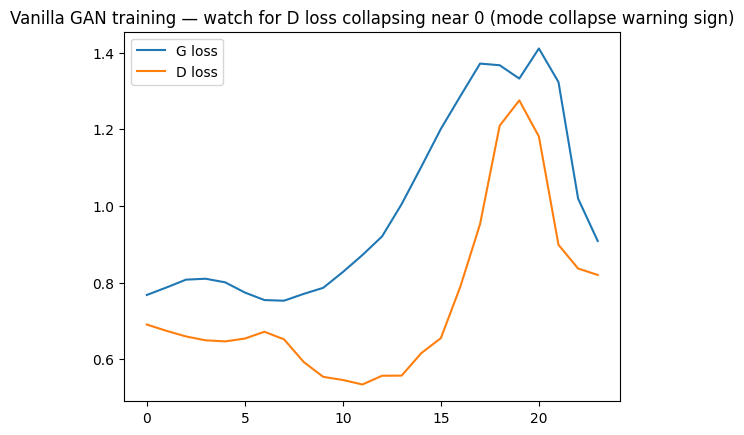

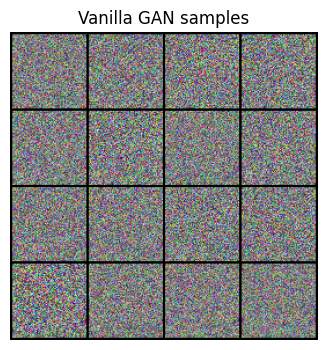

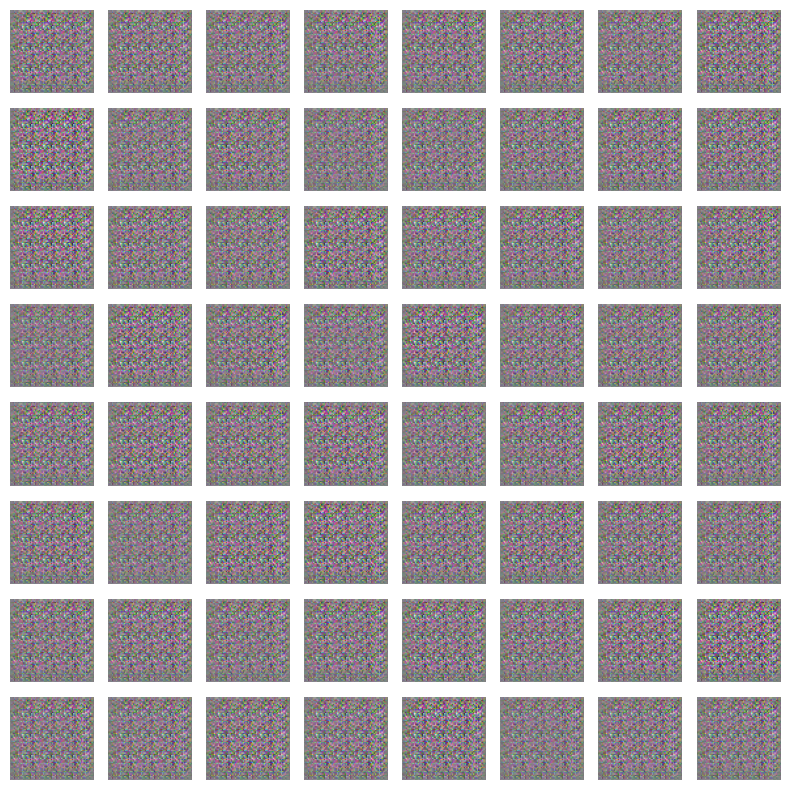

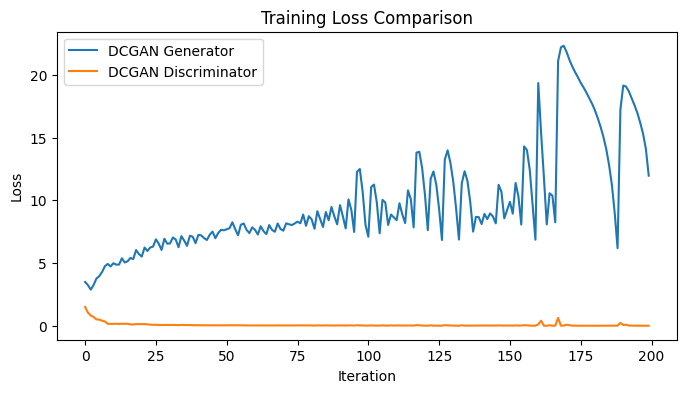

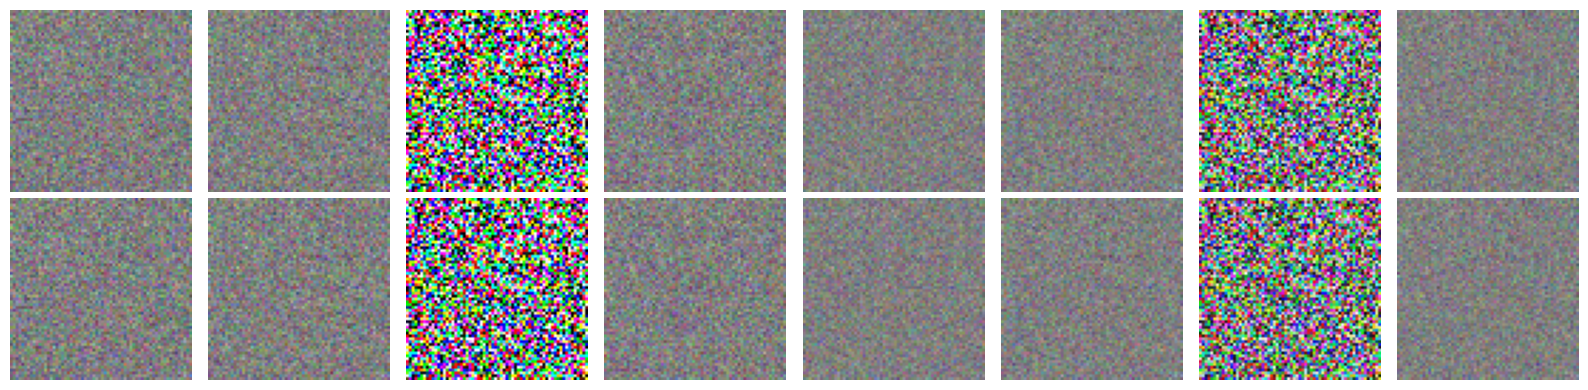

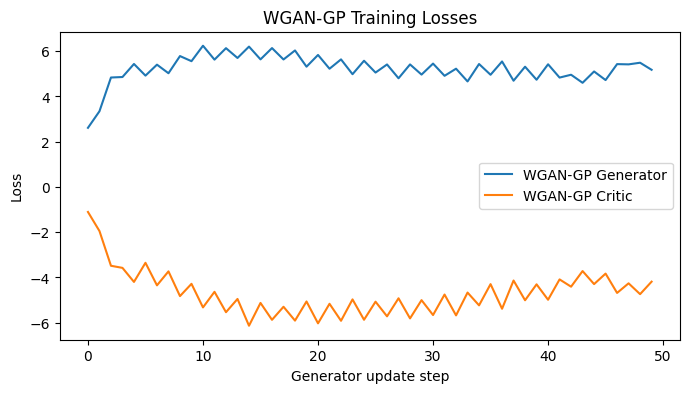

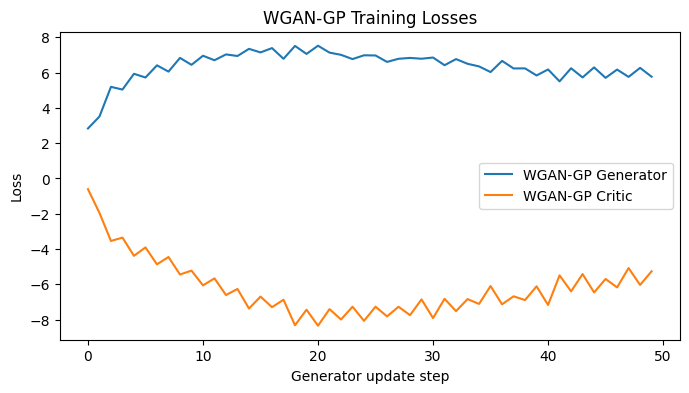

In [10]:
from generative_art_studio.models.gans import WGANCritic
from generative_art_studio.training.losses import wgan_critic_loss, wgan_generator_loss, gradient_penalty
from generative_art_studio import config

wgan_gen = DCGANGenerator(latent_dim=100, feature_maps=32).to(DEVICE)  # generator arch is unchanged
critic = WGANCritic(feature_maps=32).to(DEVICE)

# config.LR does not exist in this project, so fall back to the standard WGAN learning rate.
learning_rate = getattr(config, "LR", 2e-4)

# TODO: implement the WGAN-GP training loop:
#   for N_CRITIC steps: update critic using wgan_critic_loss + WGAN_GP_LAMBDA * gradient_penalty
#   then: one generator update using wgan_generator_loss
# Compare training-curve smoothness against the vanilla/DCGAN BCE-based runs above.

wgan_latent_dim = 100
optimizerC = optim.Adam(critic.parameters(), lr=learning_rate, betas=(0.0, 0.9))
optimizerG = optim.Adam(wgan_gen.parameters(), lr=learning_rate, betas=(0.0, 0.9))

num_epochs = 25
wgan_G_losses, wgan_C_losses = [], []

for epoch in range(num_epochs):
    data_iter = iter(dataloader)
    while True:
        # ---- Update critic N_CRITIC times ----
        critic_loss_val = None
        for _ in range(config.N_CRITIC):
            try:
                real_imgs, _ = next(data_iter)
            except StopIteration:
                break
            real_imgs = real_imgs.to(DEVICE)
            b_size = real_imgs.size(0)

            z = sample_latent(b_size, wgan_latent_dim, DEVICE)
            fake_imgs = wgan_gen(z).detach()

            critic.zero_grad()
            real_scores = critic(real_imgs)
            fake_scores = critic(fake_imgs)
            gp = gradient_penalty(critic, real_imgs, fake_imgs, DEVICE)
            c_loss = wgan_critic_loss(real_scores, fake_scores) + config.WGAN_GP_LAMBDA * gp
            c_loss.backward()
            optimizerC.step()
            critic_loss_val = c_loss.item()

        if critic_loss_val is None:
            break  # ran out of data mid-epoch

        # ---- Update generator once ----
        wgan_gen.zero_grad()
        z = sample_latent(real_imgs.size(0), wgan_latent_dim, DEVICE)
        fake_imgs = wgan_gen(z)
        fake_scores = critic(fake_imgs)
        g_loss = wgan_generator_loss(fake_scores)
        g_loss.backward()
        optimizerG.step()

        wgan_C_losses.append(critic_loss_val)
        wgan_G_losses.append(g_loss.item())

        print(f"Epoch [{epoch+1}/{num_epochs}]  Loss_C: {wgan_C_losses[-1]:.4f}  Loss_G: {wgan_G_losses[-1]:.4f}")

%matplotlib inline
# ---- Compare training-curve smoothness ----
plt.figure(figsize=(8, 4))
plt.plot(wgan_G_losses, label="WGAN-GP Generator")
plt.plot(wgan_C_losses, label="WGAN-GP Critic")
# overlay earlier runs if you saved them, e.g.:
# plt.plot(G_losses, label="Vanilla GAN Generator", linestyle="--")
# plt.plot(dc_G_losses, label="DCGAN Generator", linestyle=":")
plt.title("WGAN-GP Training Losses")
plt.xlabel("Generator update step")
plt.ylabel("Loss")
plt.legend()
plt.show()



## Reflection (for your Technical Report)

- Did you observe **mode collapse** in any model (e.g. all generated
  samples looking nearly identical)? Show a sample grid as evidence.
- Compare G/D loss curve *shape* across vanilla GAN, DCGAN, and WGAN — which
  was most stable, and why (tie back to what each loss function optimizes)?
- What did conditioning on class label change about controllability?
